# Non-homogeneous Poisson processes: events whose rate changes over time

In an ordinary Poisson process, events arrive at the same rate forever. That is
often the wrong picture. Calls to a help line are frequent at midday and rare at
3 a.m.; machines fail more often as they age; customers arrive in a lunch rush.
A **non-homogeneous Poisson process** replaces the fixed rate with a *function
of time*, `rate(t)`, and everything else about a Poisson process carries over.

`NonHomogeneousPoissonProcess` takes that function and nothing else. This
notebook builds one, checks it against the theory it should match, and shows
what it refuses to accept.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from symbulate import *
from symbulate import distributions


def seed(value=42):
    """Make the draws below reproducible."""
    distributions.rng = np.random.default_rng(value)

## A rate that varies over the day

Calls to a help line, over 24 hours: a baseline of 5 calls an hour with a peak
around noon. The rate function is just Python -- any function of one time will
do.

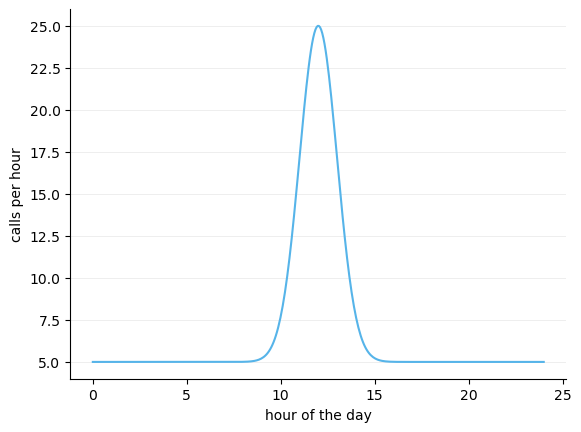

In [2]:
def call_rate(t):
    """Calls per hour at time t, peaking at midday."""
    return 5 + 20 * np.exp(-((t - 12) ** 2) / 2)


hours = np.linspace(0, 24, 400)
plt.plot(hours, [call_rate(t) for t in hours])
plt.xlabel("hour of the day")
plt.ylabel("calls per hour")
plt.show()

Hand that function to the process and draw sample paths. Each path counts calls
as the day goes on -- notice how they all climb steeply through the midday peak
and flatten out in the quiet hours on either side. An ordinary Poisson process
would climb at the same angle all day.

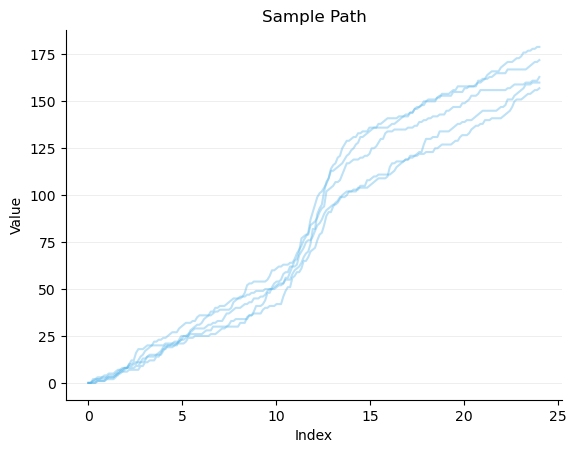

In [3]:
N = NonHomogeneousPoissonProcess(rate=call_rate)

seed()
N.sim(5).plot(tmin=0, tmax=24)

## Checking it against the theory

For a non-homogeneous Poisson process, the count by time `t` has a Poisson
distribution whose mean is the rate function added up from 0 to `t`. That
quantity is available directly as `.cumulative_rate`:

In [4]:
expected_calls = N.cumulative_rate(24)
by_hand = 5 * 24 + 20 * np.sqrt(2 * np.pi)  # integral of the rate, in closed form

print(f"cumulative_rate(24) = {expected_calls:.4f}")
print(f"integrated by hand  = {by_hand:.4f}")

cumulative_rate(24) = 170.1326
integrated by hand  = 170.1326


So the simulation should give a mean near 170.13 -- and because the count is
Poisson, its variance should land near 170.13 too.

In [5]:
seed()
calls_today = N(24).sim(2000)
print(f"simulated mean     = {calls_today.mean():.2f}")
print(f"simulated variance = {calls_today.var():.2f}")

simulated mean     = 170.40
simulated variance = 170.27


And the whole distribution should match `Poisson(cumulative_rate(24))`, not just
its mean. Two plot calls in one cell overlay, so the simulated counts and the
theoretical distribution can be compared directly.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


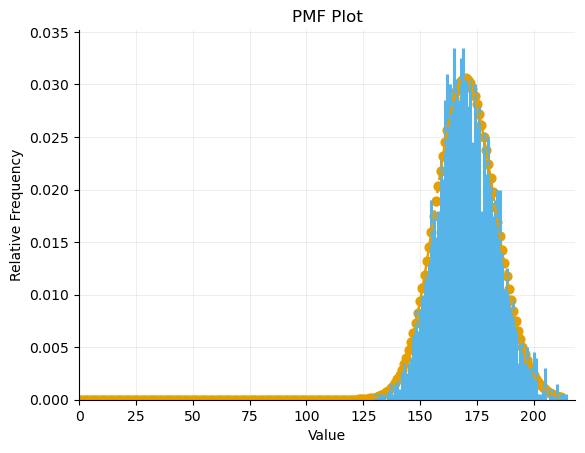

In [6]:
calls_today.plot()
Poisson(expected_calls).plot()

## How it works, and the ordinary Poisson process as a special case

The paths are generated by a **time change**. Events are drawn at a steady rate
of 1 on the "expected count" scale -- exactly what a plain Poisson process does
-- and then read back onto the clock through the cumulative rate. Counting
events before time `t` is the same as counting steady-rate events before
`cumulative_rate(t)`, which is why a varying rate needs no upper bound, no
rejected proposals, and no simulation horizon chosen in advance.

Giving a plain number instead of a function is allowed, and gives a rate that
never changes -- so it should reproduce `PoissonProcess` exactly. Both have
`E[N(4)] = rate * t = 8`.

In [7]:
seed()
varying = NonHomogeneousPoissonProcess(rate=2)(4).sim(2000).mean()
seed()
ordinary = PoissonProcess(rate=2)(4).sim(2000).mean()

print(f"NonHomogeneousPoissonProcess(rate=2)  E[N(4)] = {varying:.3f}")
print(f"PoissonProcess(rate=2)                E[N(4)] = {ordinary:.3f}")

NonHomogeneousPoissonProcess(rate=2)  E[N(4)] = 8.034
PoissonProcess(rate=2)                E[N(4)] = 8.034


## A rate that jumps: shift change

Rate functions do not have to be smooth. Here the rate is 1 for the first five
hours and 10 after that, so the second five hours should see about ten times as
many events as the first five: 5 expected, then 50.

In [8]:
def shift_change_rate(t):
    """1 event per hour before hour 5, 10 per hour after."""
    return 1 if t < 5 else 10


M = NonHomogeneousPoissonProcess(rate=shift_change_rate)
print(f"cumulative_rate(5)  = {M.cumulative_rate(5):.3f}   (expect 5)")
print(f"cumulative_rate(10) = {M.cumulative_rate(10):.3f}   (expect 55)")

seed()
first_half = M(5).sim(1000).mean()
seed()
second_half = (M(10) - M(5)).sim(1000).mean()
print(f"\nsimulated events in hours 0-5  = {first_half:.2f}")
print(f"simulated events in hours 5-10 = {second_half:.2f}")

cumulative_rate(5)  = 5.000   (expect 5)
cumulative_rate(10) = 55.000   (expect 55)

simulated events in hours 0-5  = 5.09
simulated events in hours 5-10 = 50.00


## Reliability: a rate that grows as equipment ages

The reliability-engineering standard model (the Weibull or Crow-AMSAA process)
is a non-homogeneous Poisson process with a power-law rate. With `shape > 1` the
failure rate grows over time, and the expected number of failures by time `t`
works out to `(t / scale) ** shape` -- a closed form to check against.

In [9]:
shape, scale = 2.5, 10


def wear_rate(t):
    """Failure rate of an aging machine."""
    return (shape / scale) * (t / scale) ** (shape - 1)


W = NonHomogeneousPoissonProcess(rate=wear_rate)
for t in [5, 10, 20]:
    print(
        f"t = {t:2}   cumulative_rate = {W.cumulative_rate(t):7.4f}"
        f"   (t/scale)**shape = {(t / scale) ** shape:7.4f}"
    )

t =  5   cumulative_rate =  0.1768   (t/scale)**shape =  0.1768
t = 10   cumulative_rate =  1.0000   (t/scale)**shape =  1.0000
t = 20   cumulative_rate =  5.6569   (t/scale)**shape =  5.6569


Failures cluster late, which is the whole point of the model: by time 10 fewer
than one failure is expected, and by time 20 about 5.7 are.

In [10]:
seed()
print(f"simulated failures by t=20: {W(20).sim(1000).mean():.3f}")

simulated failures by t=20: 5.750


## What the process refuses

A rate is a number of events per unit time, so it cannot be negative, cannot be
infinite, and has to be a number at all. Each of these is caught with a message
that says what to write instead.

In [11]:
bad_rates = [
    ("a rate of 0", 0),
    ("a negative number", -2),
    ("no rate at all", None),
    ("a two-argument function", lambda t, extra: t),
    ("a function returning text", lambda t: "fast"),
    ("a negative rate function", lambda t: -1),
]

for description, rate in bad_rates:
    try:
        NonHomogeneousPoissonProcess(rate=rate)
    except (TypeError, ValueError) as error:
        print(f"{description}:\n  {type(error).__name__}: {error}\n")

a rate of 0:
  ValueError: A rate given as a single number must be positive, got 0: a rate of 0 would mean no events ever occur. To have events stop and start again, give a function of time instead -- for example, rate=lambda t: 0 if t < 5 else 2 for events that only begin at time 5.

a negative number:
  ValueError: A rate given as a single number must be positive, got -2: the rate is how frequently events happen, so it cannot be negative. To have events stop and start again, give a function of time instead -- for example, rate=lambda t: 0 if t < 5 else 2 for events that only begin at time 5.

no rate at all:
  TypeError: rate must be a function of time or a positive number, got NoneType. For example, rate=lambda t: 2 + t for a rate that grows over time, rate=lambda t: 5 if t < 12 else 1 for a rate that drops at time 12, or rate=2 for a rate that never changes.

a two-argument function:
  TypeError: rate must be a function of one argument, the time t -- for example, rate=lambda t: 2 +

### Rates that only go wrong later

`rate=lambda t: 5 - t` is a perfectly good rate function up to time 5 and
nonsense after it. Refusing it outright would rule out a model that is valid
over the times being asked about, so it is accepted, and the times where it
breaks down are refused when they come up -- naming the time and the value:

In [12]:
fading = NonHomogeneousPoissonProcess(rate=lambda t: 5 - t)

print(f"cumulative_rate(3) = {fading.cumulative_rate(3)}   (fine: the rate is 2 at t=3)")
try:
    fading.cumulative_rate(8)
except ValueError as error:
    print(f"\ncumulative_rate(8) raises:\n  {error}")

cumulative_rate(3) = 10.5   (fine: the rate is 2 at t=3)

cumulative_rate(8) raises:
  rate(t) can never be negative, but at t=5.5 your rate function gives -0.5. The rate is how frequently events happen, so 0 is the smallest it can be (no events at all during that stretch of time). If your formula is meant to fade out rather than turn negative, wrap it so it flattens at 0 -- for example, rate=lambda t: max(0, 5 - t) instead of rate=lambda t: 5 - t.


### Rates that cannot be added up at all

This is the genuinely new risk in a process built on a rate *function*: adding
one up is a numerical integration, and numerical integration can return a
confidently wrong number. `rate=lambda t: 1 / t` integrates to a finite-looking
41.68 over `(0, 1)`; `rate=lambda t: t ** -2` integrates to **-1**, a negative
expected count. Symbulate checks the reported error of every integral against
its value, retries over finer and finer pieces, and raises rather than passing
on a number that looks fine:

In [13]:
for description, rate in [
    ("1 / t", lambda t: 1 / t if t > 0 else 1.0),
    ("t ** -2", lambda t: t**-2 if t > 0 else 1.0),
]:
    try:
        NonHomogeneousPoissonProcess(rate=rate).cumulative_rate(1)
    except ValueError as error:
        print(f"rate = {description}:\n  {error}\n")

rate = 1 / t:
  Symbulate could not work out the expected number of events between time 0 and time 1, because the rate function changes too sharply there to add up reliably. This usually means the rate grows without bound somewhere in that stretch of time (rate=lambda t: 1 / t does this at t=0). Check that your rate function stays finite over the times you are asking about.

rate = t ** -2:
  Symbulate could not work out the expected number of events between time 0 and time 1, because the rate function changes too sharply there to add up reliably. This usually means the rate grows without bound somewhere in that stretch of time (rate=lambda t: 1 / t does this at t=0). Check that your rate function stays finite over the times you are asking about.



A rate that changes very fast but *is* integrable is not refused -- it is
retried over smaller pieces until it adds up. Here the rate oscillates a
thousand times per unit of time, and the answer still comes out right (the exact
value is `100 + (1 - cos(100000)) / 1000`):

In [14]:
wobbly = NonHomogeneousPoissonProcess(rate=lambda t: 1 + np.sin(1000 * t))
exact = 100 + (1 - np.cos(100000)) / 1000
print(f"cumulative_rate(100) = {wobbly.cumulative_rate(100):.6f}")
print(f"exact                = {exact:.6f}")

cumulative_rate(100) = 100.001999
exact                = 100.001999


### One limitation, stated plainly

A spike far narrower than the stretch of time being integrated can be stepped
over entirely. Below, the rate is 1 everywhere plus a spike about 0.002 wide at
time 7, which contributes 1.77 expected events -- and the integration misses it,
reporting 100 instead of 101.77, with no warning that it did.

In [15]:
def spiky_rate(t):
    """Rate 1, plus a very narrow burst at time 7."""
    return 1 + 1000 * np.exp(-((t - 7) ** 2) / 1e-6)


S = NonHomogeneousPoissonProcess(rate=spiky_rate)
print(f"cumulative_rate(100) = {S.cumulative_rate(100):.4f}")
print(f"true value           = {100 + 1000 * np.sqrt(np.pi * 1e-6):.4f}")

cumulative_rate(100) = 100.0000
true value           = 101.7725


This is inherent to integrating a black-box function: nothing in the numbers
reveals the spike. Rates that vary on a scale anywhere near the times being
asked about -- daily cycles, wear, a shift change, everything above -- are
unaffected. If a rate really is a sequence of near-instantaneous bursts, model
the bursts as their own events rather than as spikes in a rate.

## Where this lives

- `symbulate/poisson_process.py` -- `NonHomogeneousPoissonProcess`,
  `NonHomogeneousPoissonProcessProbabilitySpace`,
  `NonHomogeneousPoissonProcessResult`, and the cumulative-rate machinery,
  alongside the ordinary `PoissonProcess` they generalize.
- `symbulate/tests/test_poisson_process.py` -- tests for the cumulative rate
  against closed-form integrals, the Poisson marginal, and every refusal above.
- `MODEL-DECISIONS.md`, "Decision: Non-Homogeneous Poisson Process --
  Time-Change, Not Thinning" -- why time change rather than thinning, why
  thinning is still the right tool for the Cox and Hawkes processes later, and
  the full numerical policy behind the errors shown here.